# __Deloitte Data Analytics Virtual Internship__

### Questions 
1. In which location did machines break the most?
2. What are the machines that broke most often in that location?

## 1. Load and Explore the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_json("daikibo-telemetry-data.json")
print(f"Total records: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Total records: 160704
Columns: ['deviceID', 'deviceType', 'timestamp', 'location', 'data']


,deviceID,deviceType,timestamp,location,data
0,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:00:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 27}"
1,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:10:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 27}"
2,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:20:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 26}"
3,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:30:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 24}"
4,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:40:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'healthy', 'temperature': 27}"


## 2. Extract Nested Fields
The `location` and `data` columns contain nested dictionaries. Let's flatten them.

In [3]:
# Extract location fields
df['country'] = df['location'].apply(lambda x: x['country'])
df['city'] = df['location'].apply(lambda x: x['city'])
df['area'] = df['location'].apply(lambda x: x['area'])
df['factory'] = df['location'].apply(lambda x: x['factory'])
df['section'] = df['location'].apply(lambda x: x['section'])

# Extract data fields
df['status'] = df['data'].apply(lambda x: x['status'])
df['temperature'] = df['data'].apply(lambda x: x['temperature'])

# Create a readable location label
df['location_label'] = df['factory'] + ' (' + df['city'] + ', ' + df['country'] + ')'

print(f"Unique statuses: {df['status'].unique()}")
print(f"Unique factories: {df['factory'].unique()}")
print(f"Unique device types: {df['deviceType'].unique()}")
print(f"\nStatus distribution:")
print(df['status'].value_counts())

Unique statuses: ['healthy' 'unhealthy']
Unique factories: ['daikibo-factory-meiyo' 'daikibo-factory-seiko' 'daikibo-berlin'
 'daikibo-shenzhen']
Unique device types: ['CNC' 'LaserCutter' 'HeavyDutyDrill' 'SpotWelder' 'LaserWelder'
 'MetalPress' 'Furnace' 'ConveyorBelt' 'AirWrench']

Status distribution:
status
healthy      160601
unhealthy       103
Name: count, dtype: int64


## 3. Filter Broken Machines
A machine is considered "broken" when its status is `unhealthy`.

In [4]:
# Filter for broken (unhealthy) machines
broken_df = df[df['status'] == 'unhealthy'].copy()
print(f"Total breakdown events: {len(broken_df)}")
print(f"Breakdown rate: {len(broken_df)/len(df)*100:.4f}%")
broken_df.head()

Total breakdown events: 103
Breakdown rate: 0.0641%


,deviceID,deviceType,timestamp,location,data,country,city,area,factory,section,status,temperature,location_label
5353,2fdd9006-754b-4239-bd47-371ad1aa5fbc,LaserCutter,2021-05-02 01:10:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'unhealthy', 'temperature': 23}",japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-3,unhealthy,23,"daikibo-factory-meiyo (tokyo, japan)"
5354,2fdd9006-754b-4239-bd47-371ad1aa5fbc,LaserCutter,2021-05-02 01:20:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'unhealthy', 'temperature': 27}",japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-3,unhealthy,27,"daikibo-factory-meiyo (tokyo, japan)"
5355,2fdd9006-754b-4239-bd47-371ad1aa5fbc,LaserCutter,2021-05-02 01:30:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'unhealthy', 'temperature': 25}",japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-3,unhealthy,25,"daikibo-factory-meiyo (tokyo, japan)"
7920,2fdd9006-754b-4239-bd47-371ad1aa5fbc,LaserCutter,2021-05-01 21:00:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'unhealthy', 'temperature': 26}",japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-3,unhealthy,26,"daikibo-factory-meiyo (tokyo, japan)"
33987,b2017fbe-de4d-400a-93b1-5d2856622bc8,HeavyDutyDrill,2021-05-02 21:30:00,"{'country': 'japan', 'city': 'tokyo', 'area': ...","{'status': 'unhealthy', 'temperature': 26}",japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,unhealthy,26,"daikibo-factory-meiyo (tokyo, japan)"


---
## Question 1: In which location did machines break the most?

In [5]:
# Count breakdowns by location
location_breakdown_counts = broken_df['location_label'].value_counts()
print("Breakdowns by Location:")
print("=" * 55)
for loc, count in location_breakdown_counts.items():
    print(f"  {loc}: {count} breakdowns")

top_location = location_breakdown_counts.index[0]
top_count = location_breakdown_counts.values[0]
print(f"\n>>> ANSWER: {top_location} had the MOST breakdowns with {top_count} incidents. <<<")

Breakdowns by Location:
  daikibo-factory-seiko (osaka, japan): 48 breakdowns
  daikibo-shenzhen (shenzhen, china): 42 breakdowns
  daikibo-factory-meiyo (tokyo, japan): 11 breakdowns
  daikibo-berlin (berlin, germany): 2 breakdowns

>>> ANSWER: daikibo-factory-seiko (osaka, japan) had the MOST breakdowns with 48 incidents. <<<


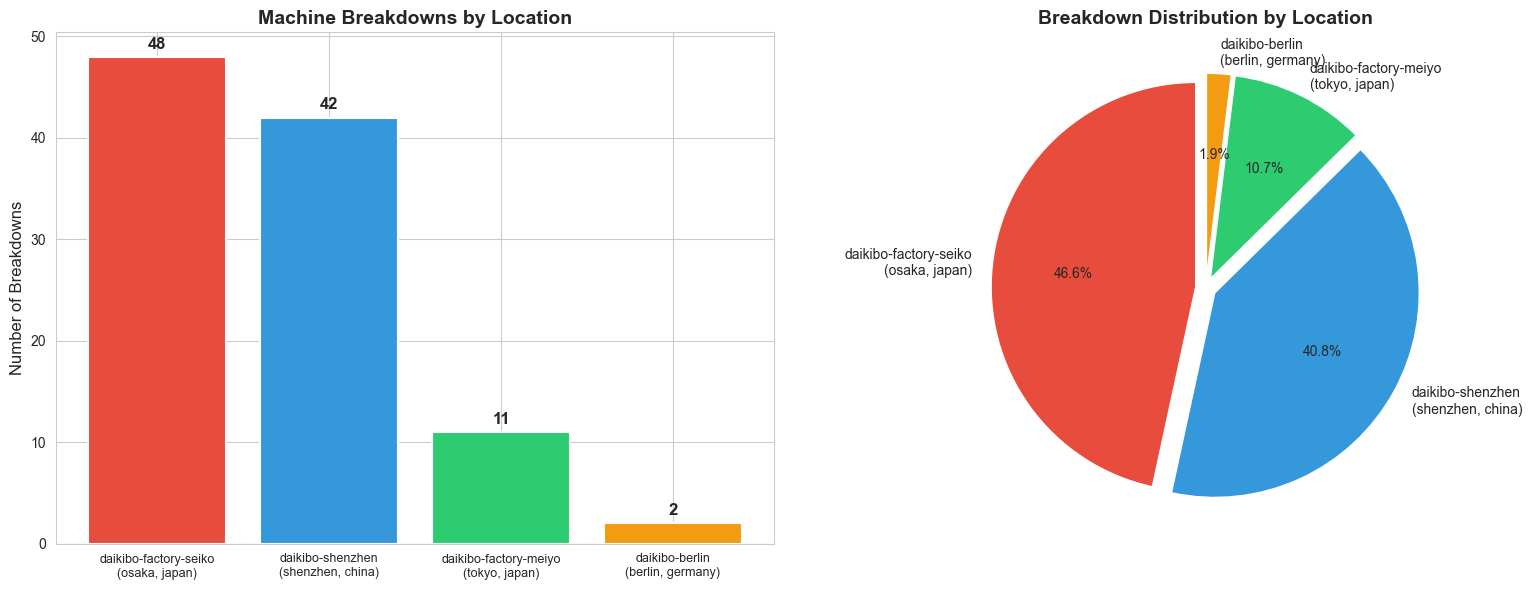

In [6]:
# Visualize breakdowns by location
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].bar(range(len(location_breakdown_counts)), 
                   location_breakdown_counts.values, 
                   color=colors[:len(location_breakdown_counts)],
                   edgecolor='white', linewidth=1.5)
axes[0].set_xticks(range(len(location_breakdown_counts)))
axes[0].set_xticklabels([l.replace(' (', '\n(') for l in location_breakdown_counts.index], 
                         fontsize=9, ha='center')
axes[0].set_ylabel('Number of Breakdowns', fontsize=12)
axes[0].set_title('Machine Breakdowns by Location', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars, location_breakdown_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(location_breakdown_counts.values, 
            labels=[l.replace(' (', '\n(') for l in location_breakdown_counts.index],
            colors=colors[:len(location_breakdown_counts)],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10},
            explode=[0.05]*len(location_breakdown_counts))
axes[1].set_title('Breakdown Distribution by Location', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('q1_breakdowns_by_location.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Question 2: What are the machines that broke most often in that location?

In [7]:
# Filter breakdowns at the top location
top_location_broken = broken_df[broken_df['location_label'] == top_location]

# Count breakdowns by device type at the top location
machine_breakdown_counts = top_location_broken['deviceType'].value_counts()

print(f"Machine breakdowns at {top_location}:")
print("=" * 55)
for machine, count in machine_breakdown_counts.items():
    print(f"  {machine}: {count} breakdowns")

top_machine = machine_breakdown_counts.index[0]
top_machine_count = machine_breakdown_counts.values[0]
print(f"\n>>> ANSWER: The {top_machine} broke the most at {top_location} with ALL {top_machine_count} breakdowns. <<<")

Machine breakdowns at daikibo-factory-seiko (osaka, japan):
  LaserWelder: 48 breakdowns

>>> ANSWER: The LaserWelder broke the most at daikibo-factory-seiko (osaka, japan) with ALL 48 breakdowns. <<<


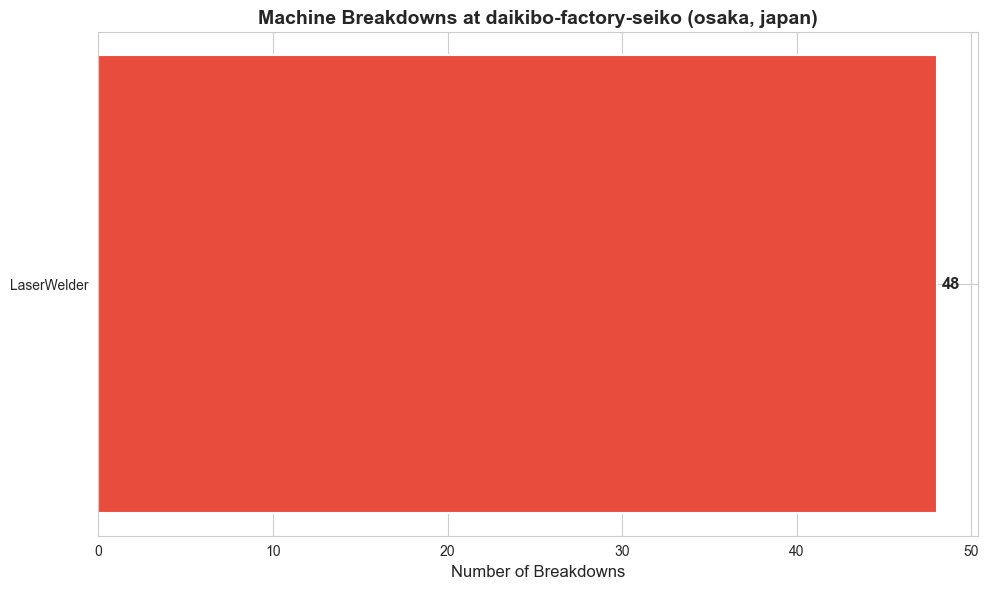

In [8]:
# Visualize machine breakdowns at top location
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(machine_breakdown_counts.index, machine_breakdown_counts.values,
               color='#e74c3c', edgecolor='white', linewidth=1.5)
ax.set_xlabel('Number of Breakdowns', fontsize=12)
ax.set_title(f'Machine Breakdowns at {top_location}', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, machine_breakdown_counts.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            str(val), ha='left', va='center', fontweight='bold', fontsize=12)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig('q2_machine_breakdowns_top_location.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Bonus: Breakdown Heatmap — All Locations × Machine Types

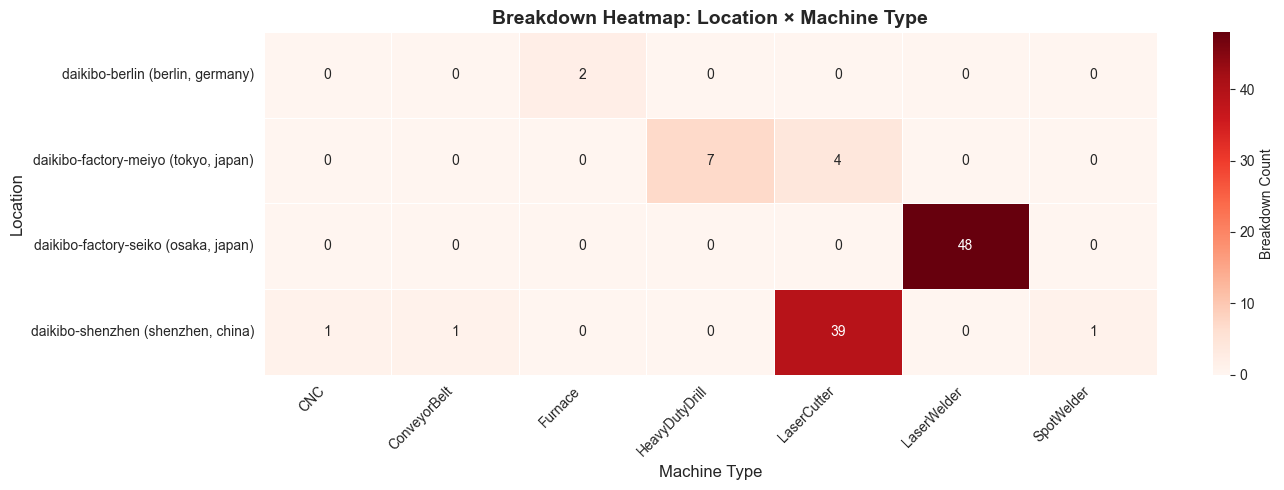

In [9]:
# Cross-tabulation of breakdowns by location and device type
heatmap_data = pd.crosstab(broken_df['location_label'], broken_df['deviceType'])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Reds', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Breakdown Count'})
ax.set_title('Breakdown Heatmap: Location × Machine Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Machine Type', fontsize=12)
ax.set_ylabel('Location', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bonus_breakdown_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

| Question | Answer |
|---|---|
| **1. Location with most breakdowns** | **daikibo-factory-seiko (Osaka, Japan)** — 48 out of 103 total breakdowns (46.6%) |
| **2. Machine that broke most at that location** | **LaserWelder** — all 48 breakdowns at this factory were from LaserWelders |